In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("../data/raw/customer_churn.xlsx")

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.shape

(7043, 33)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
df.isnull()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7039,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7040,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [7]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.nunique().sort_values()

Count                   1
Country                 1
State                   1
Phone Service           2
Dependents              2
Partner                 2
Senior Citizen          2
Gender                  2
Churn Value             2
Paperless Billing       2
Churn Label             2
Multiple Lines          3
Internet Service        3
Online Backup           3
Online Security         3
Tech Support            3
Contract                3
Streaming Movies        3
Streaming TV            3
Device Protection       3
Payment Method          4
Churn Reason           20
Tenure Months          73
Churn Score            85
City                 1129
Monthly Charges      1585
Longitude            1651
Latitude             1652
Lat Long             1652
Zip Code             1652
CLTV                 3438
Total Charges        6531
CustomerID           7043
dtype: int64

In [10]:
df['Count']

0       1
1       1
2       1
3       1
4       1
       ..
7038    1
7039    1
7040    1
7041    1
7042    1
Name: Count, Length: 7043, dtype: int64

In [11]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
df["Churn Label"].value_counts(normalize=True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [13]:
df["Churn Label"].map({'No':0,'Yes':1})

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Label, Length: 7043, dtype: int64

In [14]:
(df["Total Charges"].astype(str).str.strip() == "").sum()

np.int64(11)

In [15]:
for col in ["Count", "Country", "State"]:
    print(col, df[col].nunique())

Count 1
Country 1
State 1


In [16]:
for col in [
    "Churn Label",
    "Churn Value",
    "Churn Score",
    "Churn Reason"
]:
    print("\n", col)
    print(df[col].value_counts(dropna=False).head(10))


 Churn Label
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

 Churn Value
Churn Value
0    5174
1    1869
Name: count, dtype: int64

 Churn Score
Churn Score
80    151
71    148
77    145
67    143
68    141
76    141
70    140
69    140
78    138
72    137
Name: count, dtype: int64

 Churn Reason
Churn Reason
NaN                                          5174
Attitude of support person                    192
Competitor offered higher download speeds     189
Competitor offered more data                  162
Don't know                                    154
Competitor made better offer                  140
Attitude of service provider                  135
Competitor had better devices                 130
Network reliability                           103
Product dissatisfaction                       102
Name: count, dtype: int64


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [18]:
df.nunique().sort_values()

Count                   1
Country                 1
State                   1
Phone Service           2
Dependents              2
Partner                 2
Senior Citizen          2
Gender                  2
Churn Value             2
Paperless Billing       2
Churn Label             2
Multiple Lines          3
Internet Service        3
Online Backup           3
Online Security         3
Tech Support            3
Contract                3
Streaming Movies        3
Streaming TV            3
Device Protection       3
Payment Method          4
Churn Reason           20
Tenure Months          73
Churn Score            85
City                 1129
Monthly Charges      1585
Longitude            1651
Latitude             1652
Lat Long             1652
Zip Code             1652
CLTV                 3438
Total Charges        6531
CustomerID           7043
dtype: int64

#why these columns are dropped
| Column                             | Decision       | Reason                              |
| ---------------------------------- | -------------- | ----------------------------------- |
| CustomerID                         | Drop           | Identifier                          |
| Count                              | Drop           | Constant feature                    |
| Country                            | Drop           | Constant feature                    |
| State                              | Drop           | Constant feature                    |
| City                               | Drop initially | High-cardinality geographic feature |
| Zip Code                           | Drop initially | Geographic feature                  |
| Lat Long                           | Drop initially | Geographic feature                  |
| Latitude                           | Drop initially | Geographic feature                  |
| Longitude                          | Drop initially | Geographic feature                  |
| Churn Value                        | Drop           | Target leakage                      |
| Churn Score                        | Drop           | Target leakage                      |
| Churn Reason                       | Drop           | Target-derived information          |
| Churn Label                        | Target         | Prediction target                   |
| Remaining customer/service columns | Keep           | Candidate predictive features       |


In [19]:
columns_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Value",
    "Churn Score",
    "Churn Reason"
]

df_model = df.drop(columns=columns_to_drop)

X = df_model.drop(columns=["Churn Label"])
y = df_model["Churn Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nRemaining columns:")
print(X.columns.tolist())

X shape: (7043, 20)
y shape: (7043,)

Remaining columns:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'CLTV']


In [20]:
df_model.head()


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,5372
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,5003
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,5340


In [21]:
df_model.shape

(7043, 21)

In [22]:
y

0       Yes
1       Yes
2       Yes
3       Yes
4       Yes
       ... 
7038     No
7039     No
7040     No
7041     No
7042     No
Name: Churn Label, Length: 7043, dtype: object

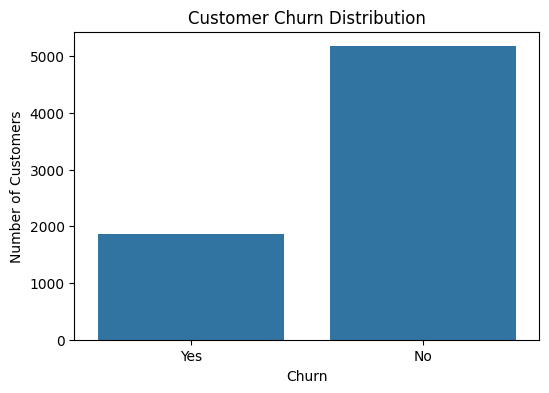

In [23]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_model,
    x="Churn Label"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [24]:
churn_percentage = (
    df_model["Churn Label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage)

Churn Label
No     73.46
Yes    26.54
Name: proportion, dtype: float64


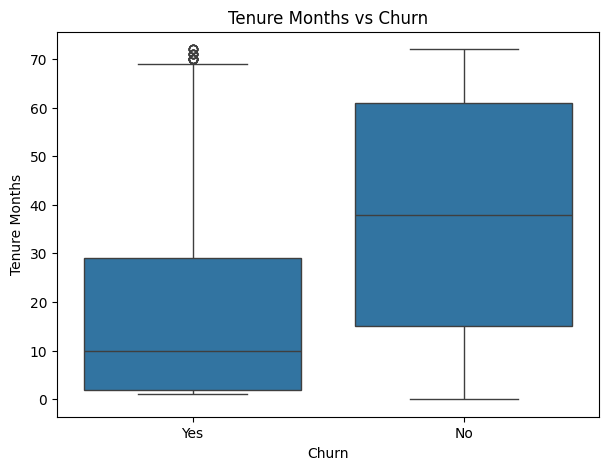

In [25]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_model,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Tenure Months vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure Months")

plt.show()

Tenure Months vs Churn — Observation

The boxplot shows a substantial difference in tenure between churned and non-churned customers. Churned customers have a much lower median tenure of approximately 10 months, while non-churned customers have a median tenure of approximately 38 months. This indicates that lower customer tenure is strongly associated with churn in this dataset. However, there is still overlap between the two groups, indicating that tenure alone cannot determine churn. Several high-tenure churned customers appear as potential outliers and should not be removed without further investigation.

In [26]:
df_model.groupby("Churn Label")["Tenure Months"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Churn Label,,,,,
No,5174,37.569965,38.0,0,72
Yes,1869,17.979133,10.0,1,72


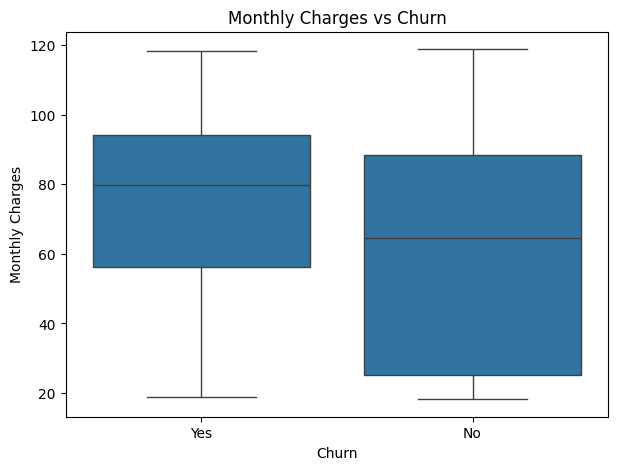

In [27]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_model,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [28]:
df_model.groupby("Churn Label")["Monthly Charges"].agg(
    ["mean", "median"]
)

,mean,median
Churn Label,,
No,61.265124,64.425
Yes,74.441332,79.650


### Monthly Charges vs Churn

Churned customers have higher average and median monthly charges
than non-churned customers. The median monthly charge is approximately
$79.65 for churned customers compared with $64.43 for non-churned
customers. This indicates that Monthly Charges is potentially an
important predictive feature.

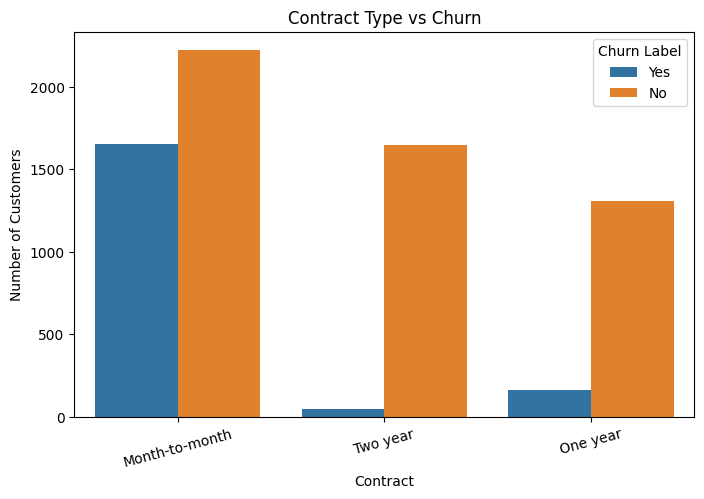

In [29]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_model,
    x="Contract",
    hue="Churn Label"
)

plt.title("Contract Type vs Churn")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

In [30]:
contract_churn = pd.crosstab(
    df_model["Contract"],
    df_model["Churn Label"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn Label,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


Contract type shows a strong association with customer churn. Month-to-month customers have a substantially higher churn rate than customers on one-year and two-year contracts.

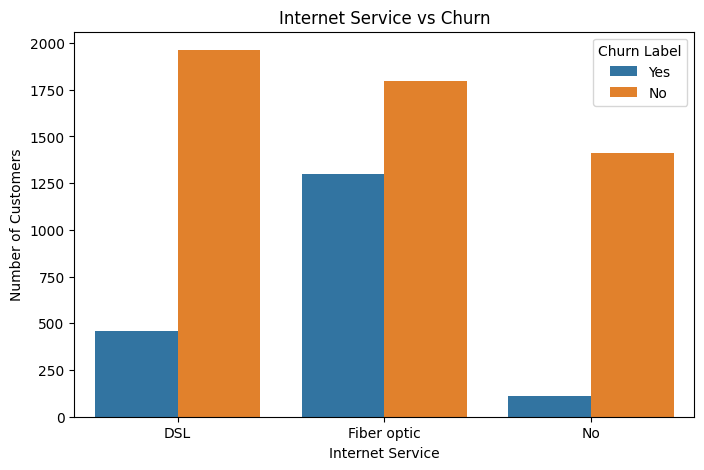

In [31]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_model,
    x="Internet Service",
    hue="Churn Label"
)

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

In [32]:
internet_churn = pd.crosstab(
    df_model["Internet Service"],
    df_model["Churn Label"],
    normalize="index"
) * 100

internet_churn.round(2)

Churn Label,No,Yes
Internet Service,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


Internet service type is strongly associated with churn. Fiber optic customers have a substantially higher churn rate than DSL and customers without internet service.

Phase-3 Production preprocessing

In [33]:
X = df_model.drop(columns=["Churn Label"])
y = df_model["Churn Label"].map({
    "No": 0,
    "Yes": 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 20)
y shape: (7043,)


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

stratify=y tells Scikit-learn:

"Split the data in such a way that the proportion of Yes and No in train and test remains approximately the same as in the original data."

In [35]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts(normalize=True))
print(y_train.value_counts(normalize=True)*100)

print("\nTesting target:")
print(y_test.value_counts(normalize=True))
print(y_train.value_counts(normalize=True)*100)
#value_counts tells no of items but if we use normalize=True it will normalize sum of all items count to 1 we can also do *100 for percentage
#here we use stratify=y so we get almost similar percentage in ytrain and ytest

Training data: (5634, 20)
Testing data: (1409, 20)

Training target:
Churn Label
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn Label
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Testing target:
Churn Label
0    0.734564
1    0.265436
Name: proportion, dtype: float64
Churn Label
0    73.464679
1    26.535321
Name: proportion, dtype: float64


In [36]:
#because your Total Charges column contains blank strings.
X_train = X_train.copy()
X_test = X_test.copy()

X_train["Total Charges"] = pd.to_numeric(
    X_train["Total Charges"],
    errors="coerce"
)

X_test["Total Charges"] = pd.to_numeric(
    X_test["Total Charges"],
    errors="coerce"
)

In [37]:
print("Missing Total Charges in train:",
      X_train["Total Charges"].isna().sum())

print("Missing Total Charges in test:",
      X_test["Total Charges"].isna().sum())

Missing Total Charges in train: 8
Missing Total Charges in test: 3


In [38]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

Categorical features:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [39]:
print(X.shape)
print(y.shape)
print(X_train.shape)
print(X_test.shape)
print(numeric_features)
categorical_features

(7043, 20)
(7043,)
(5634, 20)
(1409, 20)
['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']


['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method']

following this proces                 X
                 │
       ┌─────────┴──────────┐
       │                    │
   Numerical            Categorical
       │                    │
       ▼                    ▼
  SimpleImputer       SimpleImputer
   median             most_frequent
       │                    │
       ▼                    ▼
StandardScaler       OneHotEncoder
       │                    │
       └──────────┬─────────┘
                  ▼
         ColumnTransformer

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [41]:
#Numerical pipeline
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [42]:
#Categorical pipeline
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",OneHotEncoder(handle_unknown="ignore") #handle_unknown="ignore very important for our future FastAPI API.
        )
    ]
)

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [44]:
X_train_transformed = preprocessor.fit_transform(X_train)

X_test_transformed = preprocessor.transform(X_test)#Here never use preprocessor.fit_transform(X_test) because that would allow information from the test set to influence preprocessing.

In [45]:
print("Original training shape:", X_train.shape)
print("Transformed training shape:", X_train_transformed.shape)

print("Original testing shape:", X_test.shape)
print("Transformed testing shape:", X_test_transformed.shape)

Original training shape: (5634, 20)
Transformed training shape: (5634, 47)
Original testing shape: (1409, 20)
Transformed testing shape: (1409, 47)


In [46]:
print(type(X_train_transformed))

<class 'numpy.ndarray'>


                ML PIPELINE
                    │
        ┌───────────┴───────────┐
        │                       │
  Preprocessing              Model
        │                       │
 ┌──────┴──────┐               │
 │             │               │
Numeric     Categorical        │
 │             │               │
Impute      Impute             │
 │             │               │
Scale       OneHot             │
 └──────┬──────┘               │
        └──────────┬────────────┘
                   ▼
               Prediction

In [47]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [48]:
from sklearn.pipeline import Pipeline

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", logistic_model)
    ]
)

In [49]:
logistic_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [50]:
y_pred = logistic_pipeline.predict(X_test)
print(y_pred)
y_pred.shape

[0 1 0 ... 0 0 0]


(1409,)

In [51]:
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]
print(y_prob)
y_prob.shape

[0.07450184 0.67927556 0.09848775 ... 0.18519707 0.0056254  0.00235241]


(1409,)

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8034066713981547
Precision: 0.6456456456456456
Recall   : 0.5748663101604278
F1 Score : 0.6082036775106082
ROC-AUC  : 0.8487380195820093


In [53]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



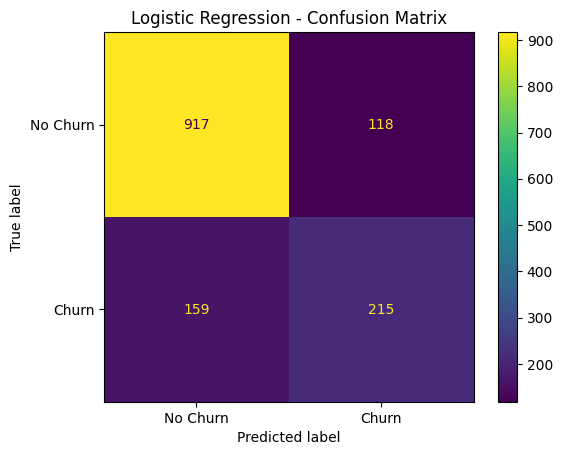

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

                    Dataset
                       │
                       ▼
               Same preprocessing
                       │
          ┌────────────┼────────────┐
          ▼            ▼            ▼
     Logistic       Random        Gradient
     Regression     Forest        Boosting
          │            │            │
          └────────────┼────────────┘
                       ▼
                Compare metrics
                       │
                       ▼
                 Best model
                       │
                       ▼
              Save production model
                       │
                       ▼
                    FastAPI
                       │
                       ▼
                    Docker

In [55]:
#now use random classifier
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)  #class_weight="balanced" tells the model to give more importance to the minority class(Y/N).



In [56]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", random_forest)
    ]
)

In [57]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [58]:
rf_pred = rf_pipeline.predict(X_test)

rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

In [59]:
print("Random Forest Results")
print("---------------------")

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Results
---------------------
Accuracy : 0.7927608232789212
Precision: 0.6404109589041096
Recall   : 0.5
F1 Score : 0.5615615615615616
ROC-AUC  : 0.8386060089384897

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



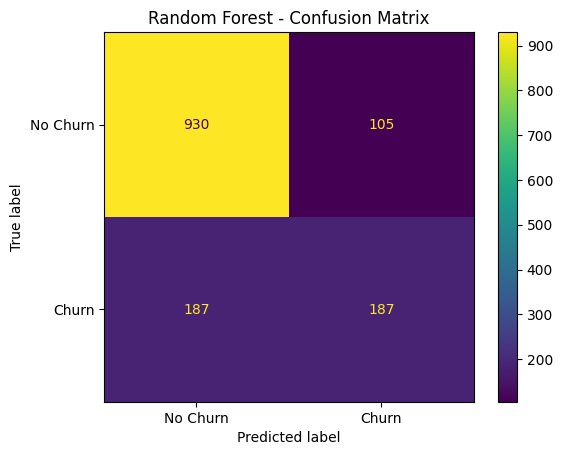

In [60]:
cm_rf = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [61]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8034,0.6456,0.5749,0.6082,0.8487
1,Random Forest,0.7928,0.6404,0.5000,0.5616,0.8386


expected Random Forest to perform better because it's a more complex algorithm.

But more complex ≠ automatically better.

That's actually a good interview discussion:

"I didn't assume a more complex model would perform better. I established Logistic Regression as a baseline and compared it against Random Forest using multiple metrics. Logistic Regression performed better on my validation/test evaluation, particularly in recall, F1 and ROC-AUC."

That's much better than saying:

"I used Random Forest because it's good for classification."

In [62]:
from sklearn.ensemble import GradientBoostingClassifier
gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [63]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", gradient_boosting)
    ]
)

In [64]:
gb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [65]:
gb_pred = gb_pipeline.predict(X_test)

gb_prob = gb_pipeline.predict_proba(X_test)[:, 1]

In [66]:
print("Gradient Boosting Results")
print("-------------------------")

print("Accuracy :", accuracy_score(y_test, gb_pred))
print("Precision:", precision_score(y_test, gb_pred))
print("Recall   :", recall_score(y_test, gb_pred))
print("F1 Score :", f1_score(y_test, gb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, gb_prob))

print("\nClassification Report:")
print(classification_report(y_test, gb_pred))

Gradient Boosting Results
-------------------------
Accuracy : 0.7998580553584103
Precision: 0.652317880794702
Recall   : 0.5267379679144385
F1 Score : 0.5828402366863905
ROC-AUC  : 0.8503151721821799

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



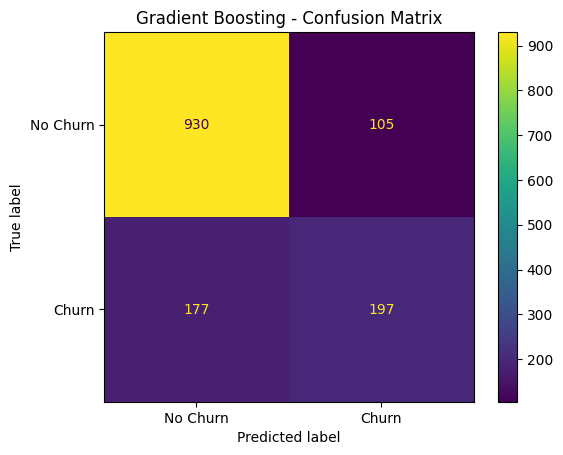

In [67]:
cm_gb = confusion_matrix(y_test, gb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Gradient Boosting - Confusion Matrix")
plt.show()

In [68]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8034,0.6456,0.5749,0.6082,0.8487
1,Random Forest,0.7928,0.6404,0.5000,0.5616,0.8386
2,Gradient Boosting,0.7999,0.6523,0.5267,0.5828,0.8503


Compare:

Logistic Regression → FN = 159
Random Forest       → FN = 187
Gradient Boosting   → FN = 177

So Logistic Regression is currently identifying more actual churners.

For this project, we'll primarily optimize around:

ROC-AUC

while also monitoring:

Recall
F1
Precision

Why ROC-AUC?

Because we're dealing with an imbalanced classification problem and want to evaluate the model's ability to distinguish churners from non-churners independently of one particular threshold.

Later we'll specifically tune the classification threshold for recall.

In [69]:
# Hyperparameter Tuning
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


In [70]:
lr_cv_scores = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Logistic Regression CV ROC-AUC:")
print(lr_cv_scores)

print("Mean:", lr_cv_scores.mean())
print("Std :", lr_cv_scores.std())

Logistic Regression CV ROC-AUC:
[0.86260563 0.83819253 0.85180069 0.87292182 0.86861081]
Mean: 0.8588262926592645
Std : 0.01252050576132556


In [71]:
rf_cv_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Random Forest CV ROC-AUC:")
print(rf_cv_scores)

print("Mean:", rf_cv_scores.mean())
print("Std :", rf_cv_scores.std())

Random Forest CV ROC-AUC:
[0.84104624 0.83186305 0.84574588 0.84860364 0.86022129]
Mean: 0.8454960223020924
Std : 0.009297437393924267


In [72]:
gb_cv_scores = cross_val_score(
    gb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Gradient Boosting CV ROC-AUC:")
print(gb_cv_scores)

print("Mean:", gb_cv_scores.mean())
print("Std :", gb_cv_scores.std())

Gradient Boosting CV ROC-AUC:
[0.86131105 0.8414643  0.85827961 0.87128997 0.87690124]
Mean: 0.8618492345421735
Std : 0.01220055434777686


In [73]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Mean ROC-AUC": [
        lr_cv_scores.mean(),
        rf_cv_scores.mean(),
        gb_cv_scores.mean()
    ],
    "Std ROC-AUC": [
        lr_cv_scores.std(),
        rf_cv_scores.std(),
        gb_cv_scores.std()
    ]
})

cv_comparison.sort_values(
    by="Mean ROC-AUC",
    ascending=False
)

,Model,Mean ROC-AUC,Std ROC-AUC
2,Gradient Boosting,0.861849,0.012201
0,Logistic Regression,0.858826,0.012521
1,Random Forest,0.845496,0.009297


Why do we care about the standard deviation?

Suppose we get:

Model A → Mean ROC-AUC = 0.850 ± 0.002
Model B → Mean ROC-AUC = 0.852 ± 0.020

Model B has a slightly higher average but much greater variation between folds.

That tells us something about the model's stability.



In [74]:
GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3
)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [75]:
param_grid = {
    "model__n_estimators": [100, 150, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3, 4]
}

In [76]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [77]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [100, 150, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [78]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(grid_search.best_score_)

Best parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}

Best CV ROC-AUC:
0.8641927072878104


In [79]:
best_gb_pipeline = grid_search.best_estimator_
print(best_gb_pipeline)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges', 'CLTV']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                            

In [80]:
print(X_test)
print(".............")
print(y_test)

      Gender Senior Citizen Partner Dependents  Tenure Months Phone Service  \
2196    Male             No     Yes         No             72           Yes   
3549  Female            Yes      No         No              8           Yes   
3515  Female             No     Yes         No             41           Yes   
5162    Male             No     Yes         No             18           Yes   
4642  Female             No     Yes         No             72           Yes   
...      ...            ...     ...        ...            ...           ...   
5660  Female             No     Yes        Yes             49           Yes   
5150    Male             No     Yes        Yes             28           Yes   
4708    Male             No      No         No              5           Yes   
5381  Female             No      No         No             56           Yes   
6000  Female             No     Yes        Yes             72           Yes   

     Multiple Lines Internet Service      Online Se

In [81]:
best_gb_pred = best_gb_pipeline.predict(X_test)

best_gb_prob = best_gb_pipeline.predict_proba(X_test)[:, 1]

In [82]:
print("Tuned Gradient Boosting Results")
print("--------------------------------")

print("Accuracy :", accuracy_score(y_test, best_gb_pred))
print("Precision:", precision_score(y_test, best_gb_pred))
print("Recall   :", recall_score(y_test, best_gb_pred))
print("F1 Score :", f1_score(y_test, best_gb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, best_gb_prob))

print("\nClassification Report:")
print(classification_report(y_test, best_gb_pred))

Tuned Gradient Boosting Results
--------------------------------
Accuracy : 0.8069552874378992
Precision: 0.6711409395973155
Recall   : 0.5347593582887701
F1 Score : 0.5952380952380952
ROC-AUC  : 0.8534953111679454

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



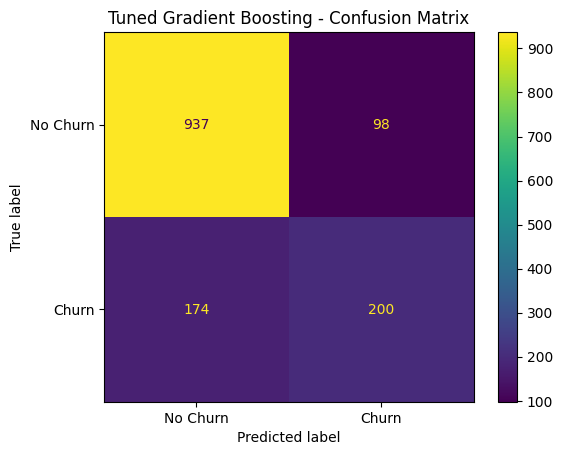

In [83]:
cm_best = confusion_matrix(y_test, best_gb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Tuned Gradient Boosting - Confusion Matrix")
plt.show()

In [84]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred),
        accuracy_score(y_test, best_gb_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred),
        precision_score(y_test, best_gb_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred),
        recall_score(y_test, best_gb_pred)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred),
        f1_score(y_test, best_gb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob),
        roc_auc_score(y_test, best_gb_prob)
    ]
})

final_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8034,0.6456,0.5749,0.6082,0.8487
1,Random Forest,0.7928,0.6404,0.5000,0.5616,0.8386
2,Gradient Boosting,0.7999,0.6523,0.5267,0.5828,0.8503
3,Tuned Gradient Boosting,0.8070,0.6711,0.5348,0.5952,0.8535


In [85]:
from sklearn.model_selection import cross_val_predict
oof_prob = cross_val_predict(
    best_gb_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]
print(oof_prob)
#oof_prob contains probability predictions for the training samples, where each prediction was generated by a model that didn't train on that particular sample.

[0.48581822 0.10722797 0.0213999  ... 0.43888841 0.05724451 0.13633524]


In [86]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in np.arange(0.30, 0.61, 0.05):

    oof_pred = (oof_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_train, oof_pred),
        "Recall": recall_score(y_train, oof_pred),
        "F1": f1_score(y_train, oof_pred)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(4)

,Threshold,Precision,Recall,F1
0,0.30,0.5558,0.7793,0.6488
1,0.35,0.5890,0.7284,0.6513
2,0.40,0.6202,0.6729,0.6455
3,0.45,0.6399,0.6074,0.6232
4,0.50,0.6733,0.5405,0.5996
5,0.55,0.7092,0.4682,0.5641
6,0.60,0.7316,0.3866,0.5059


In [87]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print(best_threshold_row)

Threshold    0.350000
Precision    0.588967
Recall       0.728428
F1           0.651316
Name: 1, dtype: float64


In [88]:
best_threshold = best_threshold_row["Threshold"]

print("Selected threshold:", best_threshold)

Selected threshold: 0.35


In [89]:
best_gb_prob

array([0.05750428, 0.73988132, 0.0833632 , ..., 0.13786745, 0.03188263,
       0.01594953], shape=(1409,))

In [90]:
final_test_pred = (
    best_gb_prob >= best_threshold
).astype(int)

In [91]:
print("Final Test Results")
print("------------------")

print(
    "Accuracy :",
    accuracy_score(y_test, final_test_pred)
)

print(
    "Precision:",
    precision_score(y_test, final_test_pred)
)

print(
    "Recall   :",
    recall_score(y_test, final_test_pred)
)

print(
    "F1 Score :",
    f1_score(y_test, final_test_pred)
)

print(
    "ROC-AUC  :",
    roc_auc_score(y_test, best_gb_prob)
)

Final Test Results
------------------
Accuracy : 0.7842441447835344
Precision: 0.5747863247863247
Recall   : 0.7192513368983957
F1 Score : 0.6389548693586699
ROC-AUC  : 0.8534953111679454


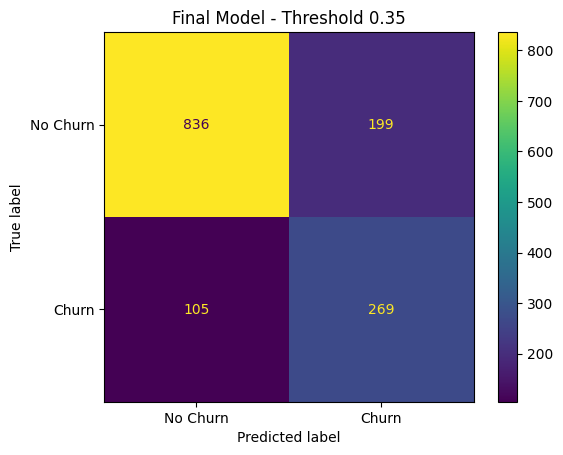

In [92]:
final_cm = confusion_matrix(
    y_test,
    final_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title(
    f"Final Model - Threshold {best_threshold:.2f}"
)

plt.show()

In [93]:
best_threshold = 0.35

final_test_pred = (
    best_gb_prob >= best_threshold
).astype(int)

In [94]:
print("Final Model Results")
print("-------------------")

print("Threshold:", best_threshold)

print("Accuracy :",
      accuracy_score(y_test, final_test_pred))

print("Precision:",
      precision_score(y_test, final_test_pred))

print("Recall   :",
      recall_score(y_test, final_test_pred))

print("F1 Score :",
      f1_score(y_test, final_test_pred))

print("ROC-AUC  :",
      roc_auc_score(y_test, best_gb_prob))

Final Model Results
-------------------
Threshold: 0.35
Accuracy : 0.7842441447835344
Precision: 0.5747863247863247
Recall   : 0.7192513368983957
F1 Score : 0.6389548693586699
ROC-AUC  : 0.8534953111679454


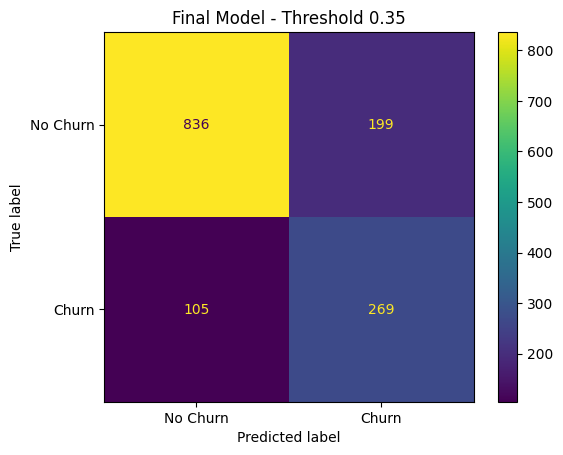

In [95]:
final_cm = confusion_matrix(
    y_test,
    final_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title(
    f"Final Model - Threshold {best_threshold}"
)

plt.show()

In [96]:
final_model_summary = {
    "model": "GradientBoostingClassifier",
    "learning_rate": 0.05,
    "max_depth": 3,
    "n_estimators": 100,
    "threshold": 0.35,
    "cv_roc_auc": 0.86419
}

final_model_summary

{'model': 'GradientBoostingClassifier',
 'learning_rate': 0.05,
 'max_depth': 3,
 'n_estimators': 100,
 'threshold': 0.35,
 'cv_roc_auc': 0.86419}

In [97]:
import joblib
joblib.dump(
    best_gb_pipeline,
    "../models/churn_model.joblib"
)

['../models/churn_model.joblib']

In [98]:
import json

threshold_config = {
    "threshold": 0.35
}

with open("../models/threshold.json", "w") as f:
    json.dump(threshold_config, f, indent=4)

In [99]:
import os

print(os.listdir("../models"))

['churn_model.joblib', 'threshold.json']


In [100]:
loaded_model = joblib.load(
    "../models/churn_model.joblib"
)

print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


In [101]:
with open("../models/threshold.json", "r") as f:
    loaded_threshold = json.load(f)

print(loaded_threshold)

{'threshold': 0.35}


In [102]:
loaded_prob = loaded_model.predict_proba(X_test)[:, 1]

loaded_pred = (
    loaded_prob >= loaded_threshold["threshold"]
).astype(int)

print(
    np.array_equal(
        loaded_pred,
        final_test_pred
    )
)

True
